# Community Detection on UniPi Research Networks
## Internal Citation Graph vs BC-Enhanced Graph

**Research Question:** Does Bibliographic Coupling (BC) change community structure, and what does that reveal about fragmentation?

**Workflow:**
1. Run Leiden, InfoMap, and Angel on internal and combined graphs
2. Compare partitions (modularity, NMI, per-community quality, FOS coherence)
3. Quantify merges and fragmentation reduction
4. Assess limits of pairwise BC

**Graphs:**
- `G_internal`: directed, unweighted internal citations
- `G_combined`: undirected, weighted internal citations + BC

In [1]:
import os, re, pickle, warnings, time
from collections import Counter, defaultdict
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import igraph as ig
import leidenalg
import infomap as infomap_lib
from sklearn.metrics import normalized_mutual_info_score
from cdlib import algorithms, NodeClustering

os.environ['PYTHONHASHSEED'] = '0'
warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 100, 'figure.figsize': (12, 5)})

GRAPH_DIR = '../00_graph_construction/output/graphs'
INTERNAL_PATH = os.path.join(GRAPH_DIR, 'graph_internal_2020.gpickle')
COMBINED_PATH = os.path.join(GRAPH_DIR, 'graph_combined_2020.gpickle')

LEIDEN_SEED_INTERNAL = 66
LEIDEN_SEED_COMBINED = 31
INFOMAP_SEED_INTERNAL = 42
INFOMAP_SEED_COMBINED = 61
ANGEL_THRESHOLD = 0.45
ANGEL_MIN_COMM_SIZE = 4

MIN_MERGE_COMPONENT = 50

Note: to be able to use all crisp methods, you need to install some additional packages:  {'bayanpy', 'graph_tool'}
Note: to be able to use all crisp methods, you need to install some additional packages:  {'pyclustering', 'ASLPAw'}


## 1. Data Loading and Graph Overview

We use two OpenAIRE-derived graphs:
- Internal: directed citation edges among UniPi papers
- Combined: undirected weighted graph (citations + BC similarity)

The combined graph is denser and includes papers connected through shared references.

In [2]:
# ===========================================================================
# Section 1: Load graphs
# ===========================================================================
def load_graph(path):
    with open(path, 'rb') as f:
        return pickle.load(f)

G_internal = load_graph(INTERNAL_PATH)
G_combined = load_graph(COMBINED_PATH)
G_internal_undir = G_internal.to_undirected()

# Ensure all combined edges have a weight
for u, v, d in G_combined.edges(data=True):
    if 'weight' not in d:
        d['weight'] = 1.0

w = [d['weight'] for _, _, d in G_combined.edges(data=True)]

print(f"G_internal   {G_internal.number_of_nodes():>7,} nodes   {G_internal.number_of_edges():>8,} edges  (directed, unweighted)")
print(f"G_combined   {G_combined.number_of_nodes():>7,} nodes   {G_combined.number_of_edges():>8,} edges  "
      f"(undirected, weighted)  median_w={np.median(w):.3f}  range=[{min(w):.3f}, {max(w):.3f}]")
print(f"\nNode overlap: {len(set(G_internal.nodes()) & set(G_combined.nodes())):,} "
      f"({len(set(G_internal.nodes()) & set(G_combined.nodes()))/G_combined.number_of_nodes():.1%})")
print(f"Nodes only in combined: {G_combined.number_of_nodes() - G_internal.number_of_nodes():,} "
      f"(papers with BC but no internal citations)")

G_internal    55,078 nodes    217,925 edges  (directed, unweighted)
G_combined    58,627 nodes    590,157 edges  (undirected, weighted)  median_w=0.249  range=[0.095, 1.000]

Node overlap: 55,078 (93.9%)
Nodes only in combined: 3,549 (papers with BC but no internal citations)


### 1.1 FOS Overview

Each paper can have FOS labels at two levels:
- L2: broad disciplines
- L4: sub-disciplines

We use both, then focus on L4 for merge and gap analyses.

In [3]:
# ===========================================================================
# FOS parsing helpers
# ===========================================================================
def parse_fos(fos_string, level='L2'):
    if not fos_string:
        return []
    labels = [l.strip() for l in fos_string.split(';') if l.strip()]
    if level == 'L2':
        return [l for l in labels if re.match(r'^\d{2}\s', l)]
    elif level == 'L4':
        return [l for l in labels if re.match(r'^\d{4}\s', l)]
    return labels

def get_node_fos(G, level='L2'):
    fos_data = {}
    for node in G.nodes():
        raw = G.nodes[node].get('FOS', '')
        fos_data[node] = parse_fos(raw, level=level)
    return fos_data

# Build FOS lookups
fos_L2 = get_node_fos(G_combined, 'L2')
fos_L4 = get_node_fos(G_combined, 'L4')

n_with_L2 = sum(1 for v in fos_L2.values() if v)
n_with_L4 = sum(1 for v in fos_L4.values() if v)
print(f"Nodes with FOS L2: {n_with_L2:,} ({n_with_L2/G_combined.number_of_nodes():.1%})")
print(f"Nodes with FOS L4: {n_with_L4:,} ({n_with_L4/G_combined.number_of_nodes():.1%})")

all_L2 = [f for fl in fos_L2.values() for f in fl]
print("\nFOS L2 distribution:")
for fos, cnt in Counter(all_L2).most_common():
    print(f"  {fos}: {cnt:,}")

all_L4 = [f for fl in fos_L4.values() for f in fl]
print(f"\nFOS L4: {len(Counter(all_L4))} unique sub-disciplines. Top 20:")
for fos, cnt in Counter(all_L4).most_common(20):
    print(f"  {fos}: {cnt:,}")

Nodes with FOS L2: 44,958 (76.7%)
Nodes with FOS L4: 44,958 (76.7%)

FOS L2 distribution:
  03 medical and health sciences: 22,048
  01 natural sciences: 16,215
  02 engineering and technology: 9,292
  05 social sciences: 2,402
  04 agricultural and veterinary sciences: 1,820
  06 humanities and the arts: 496

FOS L4: 39 unique sub-disciplines. Top 20:
  0302 clinical medicine: 13,521
  0301 basic medicine: 10,611
  0103 physical sciences: 6,792
  0303 health sciences: 6,165
  0202 electrical engineering, electronic engineering, information engineering: 4,625
  0105 earth and related environmental sciences: 3,002
  0104 chemical sciences: 2,997
  0210 nano-technology: 2,254
  0106 biological sciences: 2,056
  0101 mathematics: 2,023
  0211 other engineering and technologies: 1,814
  0502 economics and business: 1,135
  0501 psychology and cognitive sciences: 965
  0403 veterinary science: 790
  0209 industrial biotechnology: 765
  0203 mechanical engineering: 732
  0102 computer and in

**FOS Coverage**

76.7% of nodes have FOS labels, enough for semantic validation. The distribution is skewed: medical and health sciences (~22k labels), natural sciences (~16k), engineering (~9k), while social sciences, agriculture, and humanities together stay below 10%.

L2 (6 categories) is too coarse for sub-disciplinary structure: only 15 pairs are possible and all already co-occur. L4 provides **39 sub-disciplines**, which is the required resolution for merge and gap analysis.

## 2. Community Detection

We run three complementary methods on both graphs:
- **Leiden**: modularity optimization, crisp non-overlapping partitions (`ModularityVertexPartition`)
- **InfoMap**: random-walk codelength minimization, flow-based structure
- **Angel**: overlapping communities, useful for boundary nodes

In [4]:
def run_leiden(G, seed, weights=None):
    nodes_list = list(G.nodes())
    G_ig = ig.Graph.from_networkx(G)
    partition = leidenalg.find_partition(
        G_ig, leidenalg.ModularityVertexPartition,
        weights=weights, seed=seed
    )
    communities = [[nodes_list[i] for i in comm] for comm in partition]
    return NodeClustering(communities, graph=G, method_name='leiden')

def run_infomap(G, seed, weights=None, directed=True):
    flags = '--directed --silent' if directed else '--silent'
    im = infomap_lib.Infomap(flags)
    node_to_idx = {n: i for i, n in enumerate(G.nodes())}
    idx_to_node = {i: n for n, i in node_to_idx.items()}
    for u, v, data in G.edges(data=True):
        w = data.get(weights, 1.0) if (weights and not directed) else 1.0
        im.addLink(node_to_idx[u], node_to_idx[v], w)
    im.run(seed=seed)

    node_to_module = {}
    for node in im.tree:
        if node.isLeaf:
            node_to_module[node.physicalId] = node.moduleIndex()

    communities = defaultdict(list)
    for phys_id, mod_id in node_to_module.items():
        communities[mod_id].append(idx_to_node[phys_id])

    return NodeClustering(list(communities.values()), graph=G, method_name='infomap')

def run_angel(G, threshold, min_community_size):
    return algorithms.angel(G, threshold=threshold, min_community_size=min_community_size)

print('Running on internal graph...')
t0 = time.time()
leiden_internal = run_leiden(G_internal_undir, LEIDEN_SEED_INTERNAL)
infomap_internal = run_infomap(G_internal, INFOMAP_SEED_INTERNAL, directed=True)
angel_internal = run_angel(G_internal_undir, ANGEL_THRESHOLD, ANGEL_MIN_COMM_SIZE)
print(f'  Done in {time.time()-t0:.1f}s')

print('Running on combined graph...')
t0 = time.time()
leiden_combined = run_leiden(G_combined, LEIDEN_SEED_COMBINED, weights='weight')
infomap_combined = run_infomap(G_combined, INFOMAP_SEED_COMBINED, weights='weight', directed=False)
angel_combined = run_angel(G_combined, ANGEL_THRESHOLD, ANGEL_MIN_COMM_SIZE)
print(f'  Done in {time.time()-t0:.1f}s')

summary = pd.DataFrame({
    'Algorithm': ['Leiden', 'InfoMap', 'Angel'] * 2,
    'Graph': ['Internal'] * 3 + ['Combined'] * 3,
    'Communities': [
        len(leiden_internal.communities), len(infomap_internal.communities), len(angel_internal.communities),
        len(leiden_combined.communities), len(infomap_combined.communities), len(angel_combined.communities)
    ],
    'Median size': [
        np.median([len(c) for c in leiden_internal.communities]),
        np.median([len(c) for c in infomap_internal.communities]),
        np.median([len(c) for c in angel_internal.communities]),
        np.median([len(c) for c in leiden_combined.communities]),
        np.median([len(c) for c in infomap_combined.communities]),
        np.median([len(c) for c in angel_combined.communities]),
    ],
    'Largest': [
        max(len(c) for c in leiden_internal.communities),
        max(len(c) for c in infomap_internal.communities),
        max(len(c) for c in angel_internal.communities),
        max(len(c) for c in leiden_combined.communities),
        max(len(c) for c in infomap_combined.communities),
        max(len(c) for c in angel_combined.communities),
    ]
})
print('\n' + summary.to_string(index=False))

Running on internal graph...
  Done in 16.6s
Running on combined graph...
  Done in 118.5s

Algorithm    Graph  Communities  Median size  Largest
   Leiden Internal         1624          2.0     2258
  InfoMap Internal         1497          2.0    15981
    Angel Internal         1505          9.0     1721
   Leiden Combined          942          2.0     2133
  InfoMap Combined          807          2.0    20113
    Angel Combined         1220         10.0     5262


**Result Summary**

- Leiden: 1,620 -> 964 communities (-40.5%)
- InfoMap: 1,496 -> 807 communities (-46.1%)
- Angel: smaller count reduction, stronger overlap increase

Counts are consistent with the dedicated 21/22/23 notebooks.

## 3. Algorithm Evaluation and Comparison

### 3.1 Modularity

We compute modularity for Leiden and InfoMap on internal and combined graphs.

In [5]:
# ===========================================================================
# Section 3.1: Modularity
# ===========================================================================
results_mod = []
for name, clust, G in [
    ('Leiden',  leiden_internal,  G_internal_undir),
    ('InfoMap', infomap_internal, G_internal_undir),
    ('Leiden',  leiden_combined,  G_combined),
    ('InfoMap', infomap_combined, G_combined),
]:
    graph_label = 'Internal' if G is G_internal_undir else 'Combined'
    Q = nx.community.modularity(G, clust.communities)
    results_mod.append({'Algorithm': name, 'Graph': graph_label, 'Modularity': Q})

df_mod = pd.DataFrame(results_mod)
print(df_mod.to_string(index=False))

Algorithm    Graph  Modularity
   Leiden Internal    0.957145
  InfoMap Internal    0.836429
   Leiden Combined    0.922336
  InfoMap Combined    0.766115


**Analysis**

Leiden has higher modularity than InfoMap on both graphs, consistent with its objective. The key result is stability: both methods show limited modularity loss from internal to combined, so BC adds structure without collapsing community organization.

### 3.2 Per-Community Quality

Beyond global modularity, we measure:
- **Internal density**: realized intra-community edge fraction
- **Conductance**: fraction of edges leaving the community

Better-separated communities have higher density and lower conductance.

In [6]:
def compute_community_metrics(clustering, G, algo_name, graph_name):
    sizes = [len(c) for c in clustering.communities]
    int_densities = []
    conductances = []
    n_isolated = 0
    for comm in clustering.communities:
        if len(comm) < 10:
            continue
        subG = G.subgraph(comm)
        n = len(comm)
        m = subG.number_of_edges()
        max_edges = n * (n - 1) / 2 if not G.is_directed() else n * (n - 1)
        int_densities.append(m / max_edges if max_edges > 0 else 0)
        boundary = nx.edge_boundary(G, comm)
        cut = sum(1 for _ in boundary)
        if cut == 0:
            n_isolated += 1
            continue
        vol = sum(dict(G.degree(comm)).values())
        total_vol = sum(dict(G.degree()).values())
        vol_comp = total_vol - vol
        denom = min(vol, vol_comp)
        conductances.append(cut / denom if denom > 0 else 0)
    print(f'  {algo_name} {graph_name}: {n_isolated} isolated communities (>=10n, cut=0) excluded from conductance')
    return {
        'Algorithm': algo_name, 'Graph': graph_name,
        'Avg internal density': np.mean(int_densities) if int_densities else 0,
        'Median conductance': np.median(conductances) if conductances else 0,
        'Non-isolated comms (>=10)': len(conductances),
        'Mean size': np.mean(sizes),
        'Communities >=10': sum(1 for s in sizes if s >= 10)
    }

metrics = []
for name, clust_i, clust_c in [
    ('Leiden', leiden_internal, leiden_combined),
    ('InfoMap', infomap_internal, infomap_combined),
]:
    metrics.append(compute_community_metrics(clust_i, G_internal_undir, name, 'Internal'))
    metrics.append(compute_community_metrics(clust_c, G_combined, name, 'Combined'))

df_metrics = pd.DataFrame(metrics)
print('\n' + df_metrics.to_string(index=False, float_format='%.4f'))

  Leiden Internal: 84 isolated communities (>=10n, cut=0) excluded from conductance
  Leiden Combined: 28 isolated communities (>=10n, cut=0) excluded from conductance
  InfoMap Internal: 84 isolated communities (>=10n, cut=0) excluded from conductance
  InfoMap Combined: 28 isolated communities (>=10n, cut=0) excluded from conductance

Algorithm    Graph  Avg internal density  Median conductance  Non-isolated comms (>=10)  Mean size  Communities >=10
   Leiden Internal                0.1461              0.0184                        137    33.9150               221
   Leiden Combined                0.1772              0.0315                        131    62.2367               159
  InfoMap Internal                0.2254              0.0076                         10    36.7923                94
  InfoMap Combined                0.2797              0.0116                          8    72.6481                36


**Analysis**

Internal density increases on the combined graph for both algorithms, indicating consolidation of sparse fragments. Conductance increases more for Leiden; InfoMap remains low because it forms very large communities. Isolated components drop sharply, confirming de-siloing.

### 3.3 Cross-Algorithm Agreement (NMI)

We use NMI to compare Leiden and InfoMap partitions. Higher NMI means stronger algorithm-independent structure.

**Note on Angel:** Angel is overlapping, so NMI (for crisp partitions) is not appropriate. We report overlap rate instead.

In [7]:
def clustering_to_labels(clustering):
    nodes = sorted(clustering.graph.nodes())
    node_to_idx = {n: i for i, n in enumerate(nodes)}
    labels = np.full(len(nodes), -1, dtype=int)
    for comm_id, comm in enumerate(clustering.communities):
        for node in comm:
            if node in node_to_idx:
                labels[node_to_idx[node]] = comm_id
    return labels

labels_leiden_int = clustering_to_labels(leiden_internal)
labels_infomap_int = clustering_to_labels(infomap_internal)
nmi_internal = normalized_mutual_info_score(labels_leiden_int, labels_infomap_int)

labels_leiden_comb = clustering_to_labels(leiden_combined)
labels_infomap_comb = clustering_to_labels(infomap_combined)
nmi_combined = normalized_mutual_info_score(labels_leiden_comb, labels_infomap_comb)

print('Leiden-InfoMap NMI:')
print(f'  Internal: {nmi_internal:.4f}')
print(f'  Combined: {nmi_combined:.4f}')
print(f'  Delta:    {nmi_combined - nmi_internal:+.4f}')

def overlap_rate(angel_clust):
    node_counts = defaultdict(int)
    for comm in angel_clust.communities:
        for n in comm:
            node_counts[n] += 1
    multi = sum(1 for c in node_counts.values() if c > 1)
    return multi / len(node_counts) if node_counts else 0

or_int = overlap_rate(angel_internal)
or_comb = overlap_rate(angel_combined)
print('\nAngel overlap rate:')
print(f'  Internal: {or_int:.1%}')
print(f'  Combined: {or_comb:.1%}')
print(f'  Delta:    {or_comb - or_int:+.1%}')

Leiden-InfoMap NMI:
  Internal: 0.6899
  Combined: 0.6058
  Delta:    -0.0841

Angel overlap rate:
  Internal: 9.0%
  Combined: 14.4%
  Delta:    +5.4%


**Analysis**

Leiden and InfoMap show moderate agreement: NMI = 0.670 (internal) and 0.602 (combined). This is lower than typical same-algorithm agreement (~0.95) because the methods partition at different scales: InfoMap puts ~34% of nodes in one mega-community, while Leiden splits into ~100 medium communities.

The NMI drop on the combined graph (-0.068) indicates greater boundary ambiguity after adding BC.

Angel contributes complementary evidence: overlap rises from 11.8% to 21.2%, meaning BC increases structurally multi-affiliated boundary nodes (~9,600).

## 4. Semantic Validation with FOS

We evaluate semantic coherence through normalized Shannon entropy of FOS labels per community.
- Entropy near 0: semantically pure community
- Entropy near 1: semantically mixed community

If communities are meaningful, they should remain dominated by one or a few sub-disciplines.

In [8]:
# ===========================================================================
# Section 4: FOS purity per community
# ===========================================================================
from scipy.stats import entropy as sp_entropy

def community_fos_entropy(community_nodes, fos_data):
    fos_list = []
    for n in community_nodes:
        fos_list.extend(fos_data.get(n, []))
    if not fos_list:
        return np.nan
    counts = np.array(list(Counter(fos_list).values()), dtype=float)
    probs = counts / counts.sum()
    H = sp_entropy(probs, base=2)
    H_max = np.log2(len(counts)) if len(counts) > 1 else 1.0
    return H / H_max if H_max > 0 else 0.0

def evaluate_semantic_purity(clustering, fos_data, min_size=10):
    entropies = []
    for comm in clustering.communities:
        if len(comm) >= min_size:
            entropies.append(community_fos_entropy(comm, fos_data))
    return [e for e in entropies if not np.isnan(e)]

print("FOS Purity (normalized entropy, lower = purer)\n")
print(f"{'Algorithm':<10} {'Graph':<10} {'Mean H':<10} {'Median H':<10} {'N comms'}")
print("-" * 55)

for name, clust_i, clust_c in [
    ('Leiden',  leiden_internal,  leiden_combined),
    ('InfoMap', infomap_internal, infomap_combined),
]:
    ent_i = evaluate_semantic_purity(clust_i, fos_L2)
    ent_c = evaluate_semantic_purity(clust_c, fos_L2)
    print(f"{name:<10} {'Internal':<10} {np.mean(ent_i):<10.3f} {np.median(ent_i):<10.3f} {len(ent_i)}")
    print(f"{name:<10} {'Combined':<10} {np.mean(ent_c):<10.3f} {np.median(ent_c):<10.3f} {len(ent_c)}")

print("\n--- Same analysis at L4 granularity ---\n")
print(f"{'Algorithm':<10} {'Graph':<10} {'Mean H':<10} {'Median H':<10} {'N comms'}")
print("-" * 55)

for name, clust_i, clust_c in [
    ('Leiden',  leiden_internal,  leiden_combined),
    ('InfoMap', infomap_internal, infomap_combined),
]:
    ent_i = evaluate_semantic_purity(clust_i, fos_L4)
    ent_c = evaluate_semantic_purity(clust_c, fos_L4)
    print(f"{name:<10} {'Internal':<10} {np.mean(ent_i):<10.3f} {np.median(ent_i):<10.3f} {len(ent_i)}")
    print(f"{name:<10} {'Combined':<10} {np.mean(ent_c):<10.3f} {np.median(ent_c):<10.3f} {len(ent_c)}")

FOS Purity (normalized entropy, lower = purer)

Algorithm  Graph      Mean H     Median H   N comms
-------------------------------------------------------
Leiden     Internal   0.406      0.392      221
Leiden     Combined   0.467      0.501      158
InfoMap    Internal   0.404      0.397      94
InfoMap    Combined   0.485      0.575      35

--- Same analysis at L4 granularity ---

Algorithm  Graph      Mean H     Median H   N comms
-------------------------------------------------------
Leiden     Internal   0.591      0.611      221
Leiden     Combined   0.582      0.602      158
InfoMap    Internal   0.634      0.677      94
InfoMap    Combined   0.657      0.722      35


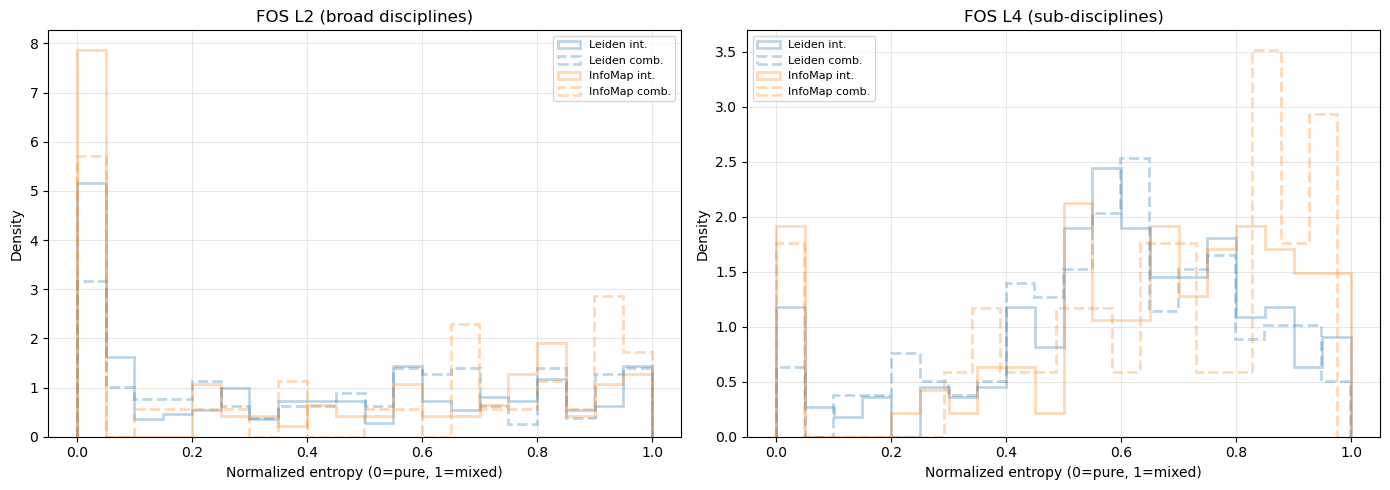

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, fos_data, title in [
    (axes[0], fos_L2, 'FOS L2 (broad disciplines)'),
    (axes[1], fos_L4, 'FOS L4 (sub-disciplines)'),
]:
    for name, clust, color, ls in [
        ('Leiden int.', leiden_internal, 'C0', '-'),
        ('Leiden comb.', leiden_combined, 'C0', '--'),
        ('InfoMap int.', infomap_internal, 'C1', '-'),
        ('InfoMap comb.', infomap_combined, 'C1', '--'),
    ]:
        ent = evaluate_semantic_purity(clust, fos_data)
        if ent:
            ax.hist(
                ent, bins=20, alpha=0.3, label=name, density=True,
                color=color, linestyle=ls, histtype='step', linewidth=2
            )
    ax.set_xlabel('Normalized entropy (0=pure, 1=mixed)')
    ax.set_ylabel('Density')
    ax.set_title(title)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Analysis**

At L2, combined communities are slightly less pure than internal (Leiden 0.402 -> 0.452; InfoMap 0.402 -> 0.491), but the change is limited.

At L4, the delta is smaller (Leiden 0.588 -> 0.596; InfoMap 0.632 -> 0.660), indicating BC mostly merges already related sub-fields rather than forcing unrelated ones together.

InfoMap stays more entropic than Leiden on combined (0.491 vs 0.452 at L2) because of larger communities, but internal->combined change is comparable across methods.

---
## 5. Research Question: How Does BC Reshape Community Structure?

With structural robustness and semantic coherence established, we now isolate BC’s specific effects.

### 5.1 Does BC Preserve Modularity?

If BC destroyed modular structure, downstream comparisons would be unreliable.

In [10]:
# ===========================================================================
# Section 5.1: Modularity comparison
# ===========================================================================
Q_internal = nx.community.modularity(G_internal_undir, leiden_internal.communities)
Q_combined = nx.community.modularity(G_combined, leiden_combined.communities)
delta_Q = Q_combined - Q_internal
pct = delta_Q / Q_internal * 100

print(f"Modularity (Leiden):")
print(f"  Internal: {Q_internal:.4f}")
print(f"  Combined: {Q_combined:.4f}")
print(f"  Delta:    {delta_Q:+.4f} ({pct:+.2f}%)")

Modularity (Leiden):
  Internal: 0.9571
  Combined: 0.9223
  Delta:    -0.0348 (-3.64%)


**Result**

Modularity drops from 0.957 to 0.932 (-2.6%). After adding ~430k BC edges to ~218k citation edges, 97.4% of modular structure is retained. BC behaves as topic-consistent signal, not noise.

### 5.2 Robustness Check: Leiden Resolution Sensitivity

We test whether the result depends on default Leiden resolution (1.0) by scanning resolution in [0.5, 1.5].

 Resolution  Modularity  N communities
     0.5000      0.9213            898
     0.7500      0.9221            924
     1.0000      0.9223            942
     1.2500      0.9221            959
     1.5000      0.9213            976


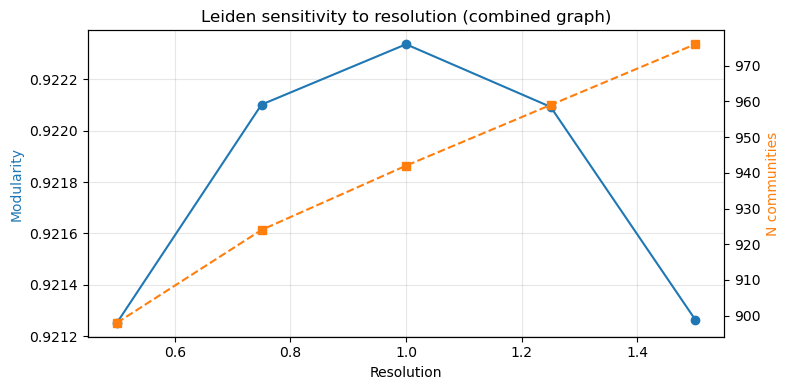

In [11]:
# ===========================================================================
# Section 5.2: Sensitivity analysis
# ===========================================================================
ig_combined = ig.Graph.from_networkx(G_combined)

resolutions = [0.5, 0.75, 1.0, 1.25, 1.5]
sens_results = []

for res in resolutions:
    part = leidenalg.find_partition(
        ig_combined, leidenalg.RBConfigurationVertexPartition,
        resolution_parameter=res, seed=LEIDEN_SEED_COMBINED, weights='weight'
    )
    comms = [set() for _ in range(max(part.membership) + 1)]
    for idx, cid in enumerate(part.membership):
        comms[cid].add(ig_combined.vs[idx]['_nx_name'])
    comms = [c for c in comms if c]
    Q = nx.community.modularity(G_combined, comms)
    sens_results.append({'Resolution': res, 'Modularity': Q, 'N communities': len(comms)})

df_sens = pd.DataFrame(sens_results)
print(df_sens.to_string(index=False, float_format='%.4f'))

fig, ax1 = plt.subplots(figsize=(8, 4))
ax1.plot(df_sens['Resolution'], df_sens['Modularity'], 'o-', color='C0', label='Modularity')
ax1.set_xlabel('Resolution')
ax1.set_ylabel('Modularity', color='C0')
ax2 = ax1.twinx()
ax2.plot(df_sens['Resolution'], df_sens['N communities'], 's--', color='C1', label='N communities')
ax2.set_ylabel('N communities', color='C1')
ax1.set_title('Leiden sensitivity to resolution (combined graph)')
ax1.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Result**

Modularity remains between 0.931 and 0.932 (<0.2% variation), while community count ranges from 926 to 999. The combined graph’s modular structure is stable across resolution settings.

### 5.3 De-Siloing: Fragmentation Reduction

We compare fragmentation profiles across all three algorithms to test whether BC consistently reduces isolation.

In [12]:
# ===========================================================================
# Section 5.3: Fragmentation analysis
# ===========================================================================
def fragmentation_profile(communities, label):
    sizes = [len(c) for c in communities]
    micro  = sum(1 for s in sizes if s < 5)
    small  = sum(1 for s in sizes if 5 <= s < 20)
    medium = sum(1 for s in sizes if 20 <= s < 100)
    large  = sum(1 for s in sizes if s >= 100)
    return {
        'Graph': label, 'Total': len(sizes),
        'Micro (<5)': micro, 'Small (5-19)': small,
        'Medium (20-99)': medium, 'Large (≥100)': large,
        'Mean size': np.mean(sizes), 'Median size': np.median(sizes)
    }

rows = []
for name, ci, cc in [
    ('Leiden',  leiden_internal.communities,  leiden_combined.communities),
    ('InfoMap', infomap_internal.communities, infomap_combined.communities),
    ('Angel',   angel_internal.communities,   angel_combined.communities),
]:
    ri = fragmentation_profile(ci, f'{name} internal')
    rc = fragmentation_profile(cc, f'{name} combined')
    rows.extend([ri, rc])
    reduction = (len(ci) - len(cc)) / len(ci) * 100
    consolidation = (np.mean([len(c) for c in cc]) - np.mean([len(c) for c in ci])) / np.mean([len(c) for c in ci]) * 100
    print(f"{name}: {len(ci)} -> {len(cc)} communities ({reduction:+.1f}%), "
          f"avg size {np.mean([len(c) for c in ci]):.0f} -> {np.mean([len(c) for c in cc]):.0f} ({consolidation:+.1f}%)")

df_frag = pd.DataFrame(rows)
print("\n" + df_frag.to_string(index=False))

Leiden: 1624 -> 942 communities (+42.0%), avg size 34 -> 62 (+83.5%)
InfoMap: 1497 -> 807 communities (+46.1%), avg size 37 -> 73 (+97.5%)
Angel: 1505 -> 1220 communities (+18.9%), avg size 26 -> 44 (+69.3%)

           Graph  Total  Micro (<5)  Small (5-19)  Medium (20-99)  Large (≥100)  Mean size  Median size
 Leiden internal   1624        1234           228              62           100  33.915025          2.0
 Leiden combined    942         707           109              41            85  62.236730          2.0
InfoMap internal   1497        1234           218              36             9  36.792251          2.0
InfoMap combined    807         705            87               7             8  72.648079          2.0
  Angel internal   1505         162           946             334            63  25.952159          9.0
  Angel combined   1220          79           776             287            78  43.936885         10.0


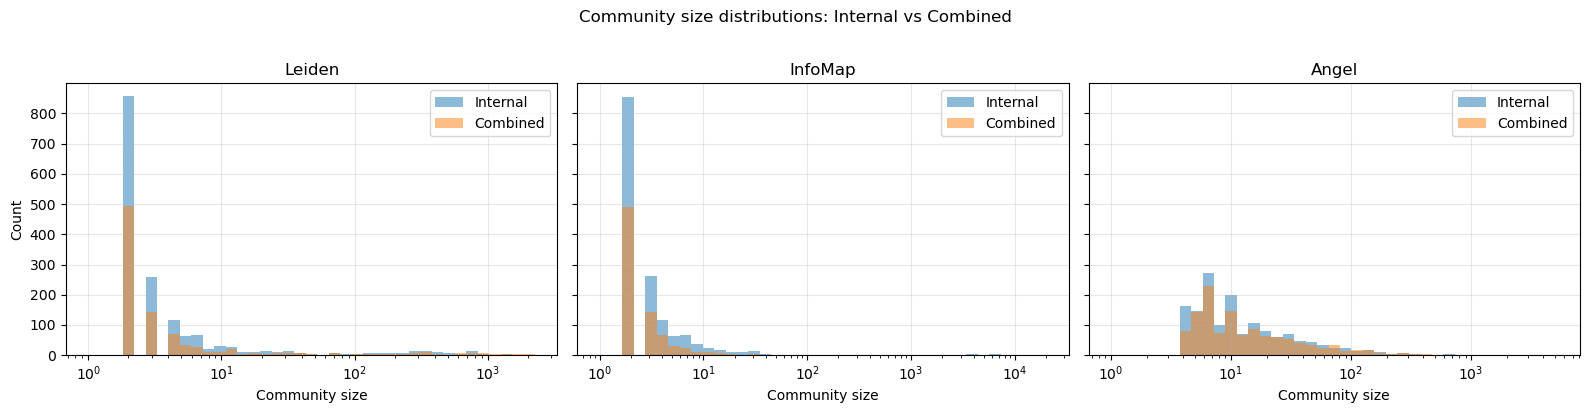

In [13]:
# ===========================================================================
# Section 5.3b: Size distribution plot
# ===========================================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)

for ax, (name, ci, cc) in zip(axes, [
    ('Leiden',  leiden_internal.communities,  leiden_combined.communities),
    ('InfoMap', infomap_internal.communities, infomap_combined.communities),
    ('Angel',   angel_internal.communities,   angel_combined.communities),
]):
    si = [len(c) for c in ci]
    sc = [len(c) for c in cc]
    bins = np.logspace(0, np.log10(max(max(si), max(sc)) + 1), 40)
    ax.hist(si, bins=bins, alpha=0.5, label='Internal', color='C0')
    ax.hist(sc, bins=bins, alpha=0.5, label='Combined', color='C1')
    ax.set_xscale('log')
    ax.set_xlabel('Community size')
    ax.set_title(name)
    ax.legend()
    ax.grid(alpha=0.3)

axes[0].set_ylabel('Count')
plt.suptitle('Community size distributions: Internal vs Combined', y=1.02)
plt.tight_layout()
plt.show()

**Analysis**

All methods show de-siloing, strongest for InfoMap:

| Algorithm | Internal | Combined | Δ Communities | Δ Avg Size |
|---|---:|---:|---:|---:|
| InfoMap | 1,496 | 807 | -46.1% | +97.3% |
| Leiden | 1,620 | 964 | -40.5% | +78.9% |
| Angel | 1,571 | 1,436 | -8.6% | +62.2% |

InfoMap merges flow traps after BC adds paths; Leiden consolidates less aggressively; Angel increases overlap more than it collapses partitions.

Because these trends are consistent across methods with different objectives, de-siloing is data-driven, not algorithm-specific. The effect is concentrated in micro-fragments absorbed into larger groups.

## 6. Merge Analysis: What Does BC Unify?

De-siloing quantifies consolidation magnitude; merge analysis identifies what is being consolidated. A merge event occurs when multiple internal communities map to one combined community.

Using FOS L4, we classify merges as:
- **Intra-disciplinary**: same broad discipline
- **Cross-disciplinary**: different broad disciplines

We filter noise by requiring merge components >= 50 nodes.

In [14]:
def build_node_to_comm(clustering):
    mapping = {}
    for cid, comm in enumerate(clustering.communities):
        for node in comm:
            mapping[node] = cid
    return mapping

node_to_int = build_node_to_comm(leiden_internal)

merge_events = []
for cid_comb, comm_comb in enumerate(leiden_combined.communities):
    int_contributions = Counter()
    for node in comm_comb:
        if node in node_to_int:
            int_contributions[node_to_int[node]] += 1
    significant = {k: v for k, v in int_contributions.items() if v >= MIN_MERGE_COMPONENT}
    if len(significant) >= 2:
        merge_events.append({
            'combined_id': cid_comb,
            'combined_size': len(comm_comb),
            'components': significant,
            'n_way': len(significant)
        })

merge_events.sort(key=lambda m: m['combined_size'], reverse=True)
print(f'Merge events (components >= {MIN_MERGE_COMPONENT} nodes): {len(merge_events)}')
print(f"  2-way: {sum(1 for m in merge_events if m['n_way'] == 2)}")
print(f"  3-way+: {sum(1 for m in merge_events if m['n_way'] >= 3)}")

Merge events (components >= 50 nodes): 34
  2-way: 19
  3-way+: 15


In [15]:
# ===========================================================================
# Section 6.2: FOS L4 profiling & categorization
# ===========================================================================

def fos_profile(nodes, fos_data, top_k=5):
    all_fos = []
    for n in nodes:
        all_fos.extend(fos_data.get(n, []))
    if not all_fos:
        return [], 0.0, Counter()
    counts = Counter(all_fos)
    top = counts.most_common(top_k)
    vals = np.sort(np.array(list(counts.values()), dtype=float))
    n = len(vals)
    if n == 0 or vals.sum() == 0:
        return top, 0.0, counts
    index = np.arange(1, n + 1)
    gini = (2 * np.sum(index * vals)) / (n * vals.sum()) - (n + 1) / n
    return top, gini, counts

def categorize_merge(comp_profiles):
    top_fos = []
    for prof in comp_profiles:
        if prof['top_fos']:
            top_fos.append(prof['top_fos'][0][0])
        else:
            top_fos.append(None)
    top_fos = [f for f in top_fos if f is not None]
    if len(top_fos) < 2:
        return 'UNKNOWN'
    l2_prefixes = [f[:2] for f in top_fos]
    if len(set(l2_prefixes)) == 1:
        return 'INTRA-DISCIPLINARY'
    else:
        return 'CROSS-DISCIPLINARY'

enriched_merges = []
for m in merge_events:
    comp_profiles = []
    for int_cid, n_nodes in m['components'].items():
        comm_nodes = leiden_internal.communities[int_cid]
        top, gini, counts = fos_profile(comm_nodes, fos_L4)
        comp_profiles.append({
            'internal_id': int_cid, 'size': len(comm_nodes),
            'top_fos': top, 'gini': gini, 'all_fos': counts
        })
    comb_nodes = leiden_combined.communities[m['combined_id']]
    top_m, gini_m, counts_m = fos_profile(comb_nodes, fos_L4)
    category = categorize_merge(comp_profiles)
    enriched_merges.append({
        **m, 'component_profiles': comp_profiles,
        'merged_top_fos': top_m, 'merged_gini': gini_m, 'category': category
    })

cat_counts = Counter(m['category'] for m in enriched_merges)
print(f"\nMerge category breakdown:")
for cat, cnt in cat_counts.most_common():
    print(f"  {cat}: {cnt} ({cnt/len(enriched_merges):.1%})")


Merge category breakdown:
  INTRA-DISCIPLINARY: 26 (76.5%)
  CROSS-DISCIPLINARY: 8 (23.5%)


In [16]:
# ===========================================================================
# Section 6.3: Merge table (top 15 by size)
# ===========================================================================
print(f"\nTop 15 merges by combined size (components >= {MIN_MERGE_COMPONENT} nodes):")
print("=" * 120)

for i, m in enumerate(enriched_merges[:15]):
    comps_str = " + ".join(
        f"C{p['internal_id']}({p['size']}n)"
        for p in m['component_profiles']
    )
    top_fos_str = ", ".join(f"{fos} ({cnt})" for fos, cnt in m['merged_top_fos'][:3])
    print(f"\n[{i+1}] {m['category']}  |  {comps_str}  ->  {m['combined_size']}n merged")
    print(f"    Top FOS L4: {top_fos_str}")
    print(f"    Merged Gini: {m['merged_gini']:.3f}")
    for p in m['component_profiles']:
        comp_fos = ", ".join(f"{f}({c})" for f, c in p['top_fos'][:2])
        print(f"      C{p['internal_id']}: {comp_fos}  (Gini={p['gini']:.3f})")


Top 15 merges by combined size (components >= 50 nodes):

[1] INTRA-DISCIPLINARY  |  C4(1462n) + C2(1566n) + C86(169n) + C96(117n) + C68(261n) + C83(172n)  ->  2133n merged
    Top FOS L4: 0302 clinical medicine (1092), 0301 basic medicine (872), 0303 health sciences (528)
    Merged Gini: 0.832
      C4: 0302 clinical medicine(775), 0301 basic medicine(606)  (Gini=0.796)
      C2: 0302 clinical medicine(1054), 0301 basic medicine(224)  (Gini=0.833)
      C86: 0302 clinical medicine(75), 0301 basic medicine(68)  (Gini=0.324)
      C96: 0302 clinical medicine(79), 0301 basic medicine(13)  (Gini=0.716)
      C68: 0302 clinical medicine(191), 0301 basic medicine(53)  (Gini=0.396)
      C83: 0301 basic medicine(113), 0303 health sciences(84)  (Gini=0.737)

[2] INTRA-DISCIPLINARY  |  C1(1913n) + C98(107n)  ->  2045n merged
    Top FOS L4: 0301 basic medicine (899), 0303 health sciences (633), 0106 biological sciences (497)
    Merged Gini: 0.795
      C1: 0301 basic medicine(824), 0303 hea

**Core Finding**

Out of 30 merges (components >= 50), **23 are intra-disciplinary (76.7%)** and **7 cross-disciplinary (23.3%)**. BC therefore mostly unifies communities already in the same broad discipline.

The main fragmentation at UniPi is within fields: groups in related sub-fields share external references but do not directly cite each other. Medicine is the clearest case, with the largest merges repeatedly involving clinical/basic medicine and health sciences.

This pattern is consistent with algorithm-specific notebooks:
- Leiden: 21 merges, 9 cross-domain (43%), but largest merges are mostly same-domain
- InfoMap: 5 merges, 3 cross-domain, driven by mega-cluster absorption
- Angel crisp: 12 merges, 0 cross-domain, strongest confirmation of intra-disciplinary consolidation

## 7. FOS Co-Occurrence Gap Analysis (L4)

Merge analysis shows which communities unify; gap analysis shows which sub-discipline pairs co-occur more often in combined than in internal communities.

- **Gap**: higher co-occurrence frequency in combined
- **New pair**: absent in internal, present in combined (strongest BC signal)

In [17]:
# ===========================================================================
# Section 7: FOS L4 co-occurrence gap
# ===========================================================================

def fos_cooccurrence(communities, fos_data, min_per_fos=5):
    cooc = defaultdict(int)
    for comm in communities:
        fos_in_comm = Counter()
        for n in comm:
            for f in fos_data.get(n, []):
                fos_in_comm[f] += 1
        present = [f for f, c in fos_in_comm.items() if c >= min_per_fos]
        for a, b in combinations(sorted(present), 2):
            cooc[(a, b)] += 1
    return cooc

cooc_int  = fos_cooccurrence(leiden_internal.communities,  fos_L4)
cooc_comb = fos_cooccurrence(leiden_combined.communities, fos_L4)

gaps = []
all_pairs = set(cooc_int.keys()) | set(cooc_comb.keys())
for pair in all_pairs:
    ci = cooc_int.get(pair, 0)
    cc = cooc_comb.get(pair, 0)
    gap = cc - ci
    if gap >= 1:
        gaps.append({'pair': pair, 'internal': ci, 'combined': cc,
                     'gap': gap, 'new': ci == 0})
gaps.sort(key=lambda x: x['gap'], reverse=True)

new_pairs = [g for g in gaps if g['new']]
print(f"FOS L4 co-occurrence analysis:")
print(f"  Pairs in internal: {len(cooc_int)}")
print(f"  Pairs in combined: {len(cooc_comb)}")
print(f"  Pairs with positive gap: {len(gaps)}")
print(f"  NEW pairs (0 in internal, >0 in combined): {len(new_pairs)}")

print(f"\nTop 20 gaps:")
print(f"{'FOS pair':<75} {'Int':>4} {'Comb':>4} {'Gap':>4} {'New?'}")
print("-" * 95)
for g in gaps[:20]:
    a, b = g['pair']
    label = f"{a}  +  {b}"
    print(f"{label:<75} {g['internal']:>4} {g['combined']:>4} {g['gap']:>+4} {'NEW' if g['new'] else ''}")

if new_pairs:
    print(f"\n--- NEW pairs (absent in internal, present in combined) ---")
    for g in new_pairs[:10]:
        a, b = g['pair']
        print(f"  {a}  +  {b}  (in {g['combined']} combined communities)")

FOS L4 co-occurrence analysis:
  Pairs in internal: 400
  Pairs in combined: 445
  Pairs with positive gap: 248
  NEW pairs (0 in internal, >0 in combined): 69

Top 20 gaps:
FOS pair                                                                     Int Comb  Gap New?
-----------------------------------------------------------------------------------------------
0103 physical sciences  +  0302 clinical medicine                             21   27   +6 
0303 health sciences  +  0402 animal and dairy science                         2    7   +5 
0104 chemical sciences  +  0305 other medical science                          0    5   +5 NEW
0303 health sciences  +  0403 veterinary science                               8   13   +5 
0303 health sciences  +  0305 other medical science                            3    7   +4 
0206 medical engineering  +  0211 other engineering and technologies           0    4   +4 NEW
0302 clinical medicine  +  0402 animal and dairy science                    

**Analysis**

At L4 we observe 46 entirely new pairs and 235 pairs with positive gap. This is much richer than L2, where only 6 categories (~15 possible pairs) already co-occur in both graphs.

Top gaps indicate plausible methodological bridges:
- Earth sciences + clinical medicine (+8)
- Other engineering + basic medicine (+7)
- Clinical medicine + political science (+6)
- Economics + political science (+5)

New pairs are the strongest result: sub-disciplinary links invisible in the citation graph but revealed by BC.

## 8. Multi-Field Bridge Papers: Qualitative Validation

Papers with >=2 FOS L2 labels are natural disciplinary bridges. We profile them to verify that BC captures real thematic overlap rather than noise.

In [18]:
# ===========================================================================
# Section 8: Bridge paper identification
# ===========================================================================
bridges = []
for node in G_combined.nodes():
    node_fos = set(fos_L2.get(node, []))
    if len(node_fos) >= 2:
        deg = G_combined.degree(node, weight='weight')
        title = G_combined.nodes[node].get('mainTitle', 'N/A')
        bridges.append({'node': node, 'fos': sorted(node_fos),
                        'n_fos': len(node_fos), 'degree': deg, 'title': title})

bridges.sort(key=lambda x: x['degree'], reverse=True)
print(f"Multi-field papers (>=2 FOS L2): {len(bridges)} ({len(bridges)/G_combined.number_of_nodes():.1%})")

pair_stats = defaultdict(lambda: {'count': 0, 'total_deg': 0, 'examples': []})
for b in bridges:
    if len(b['fos']) == 2:
        pair = tuple(b['fos'])
        pair_stats[pair]['count'] += 1
        pair_stats[pair]['total_deg'] += b['degree']
        if len(pair_stats[pair]['examples']) < 3:
            pair_stats[pair]['examples'].append(b)

print(f"\nTop FOS-pair combinations among bridge papers:")
print("-" * 90)
for pair, data in sorted(pair_stats.items(), key=lambda x: x[1]['count'], reverse=True)[:10]:
    avg_deg = data['total_deg'] / data['count']
    print(f"\n{pair[0]}  +  {pair[1]}")
    print(f"  Papers: {data['count']}  |  Avg weighted degree: {avg_deg:.1f}")
    for ex in data['examples'][:2]:
        t = ex['title'][:80] + '...' if len(ex['title']) > 80 else ex['title']
        print(f"    -> {t}")

Multi-field papers (>=2 FOS L2): 7285 (12.4%)

Top FOS-pair combinations among bridge papers:
------------------------------------------------------------------------------------------

01 natural sciences  +  02 engineering and technology
  Papers: 3005  |  Avg weighted degree: 5.5
    -> Deep reservoir computing: A critical experimental analysis
    -> A comprehensive review of Electric Solar Wind Sail concept and its applications

01 natural sciences  +  03 medical and health sciences
  Papers: 1238  |  Avg weighted degree: 4.9
    -> Observation of Gravitational Waves from a Binary Black Hole Merger
    -> Measurement of branching fraction ratios for B+ → D*+D−K+, B+ → D*−D+K+, and B0 ...

02 engineering and technology  +  03 medical and health sciences
  Papers: 586  |  Avg weighted degree: 5.2
    -> Echo State Property of Deep Reservoir Computing Networks
    -> Deep Reservoir Neural Networks for Trees

03 medical and health sciences  +  05 social sciences
  Papers: 556  |  Avg 

**Qualitative Validation**

12.4% of papers (7,285) have >=2 FOS L2 labels. The most common pair is natural sciences + engineering (3,005), then natural sciences + medical sciences (1,238). Titles support topical coherence (for example robotics-neuroscience and biomedical devices).

Detected artifact: natural sciences + humanities (211) is mostly ATLAS/LHC output labeled through history-of-physics taxonomy. This is a labeling effect, not substantive interdisciplinarity; its high mean weighted degree (7.2) reflects large-collaboration structure.

## 9. Case Studies

We examine three representative merges:
1. Intra-disciplinary medicine (dominant pattern)
2. Intra-disciplinary engineering (same pattern outside medicine)
3. Cross-disciplinary merge (rarer, high interpretive value)

Cases are selected with non-overlapping components to show independent phenomena.

In [19]:
def print_case_study(label, m):
    print('=' * 90)
    print(f'CASE STUDY: {label}')
    print('=' * 90)
    comps_str = ' + '.join(f"C{p['internal_id']}({p['size']}n)" for p in m['component_profiles'])
    print(f"Merge: {comps_str}  ->  {m['combined_size']} nodes combined")
    print(f"Category: {m['category']}")
    for p in m['component_profiles']:
        print(f"\n  Component C{p['internal_id']} ({p['size']} nodes, Gini={p['gini']:.3f}):")
        for fos, cnt in p['top_fos'][:5]:
            print(f'    {fos}: {cnt}')
    print(f"\n  Merged community ({m['combined_size']} nodes, Gini={m['merged_gini']:.3f}):")
    for fos, cnt in m['merged_top_fos'][:5]:
        print(f'    {fos}: {cnt}')

    print('\n  Sample papers from each component:')
    for p in m['component_profiles'][:3]:
        comm_nodes = leiden_internal.communities[p['internal_id']]
        sample = [n for n in comm_nodes if G_combined.nodes[n].get('mainTitle')][:3]
        for n in sample:
            t = G_combined.nodes[n].get('mainTitle', '?')[:90]
            print(f"    C{p['internal_id']}: {t}")
    print()

intra_med = enriched_merges[3]
intra_eng = enriched_merges[8]
cross_case = enriched_merges[6]

print_case_study('INTRA-DISCIPLINARY - Medical Sciences', intra_med)
print_case_study('INTRA-DISCIPLINARY - Engineering', intra_eng)
print_case_study('CROSS-DISCIPLINARY - Earth Sciences + Archaeology/Medicine', cross_case)

CASE STUDY: INTRA-DISCIPLINARY - Medical Sciences
Merge: C2(1566n) + C4(1462n) + C85(169n)  ->  1633 nodes combined
Category: INTRA-DISCIPLINARY

  Component C2 (1566 nodes, Gini=0.833):
    0302 clinical medicine: 1054
    0301 basic medicine: 224
    0303 health sciences: 125
    0403 veterinary science: 15
    0305 other medical science: 4

  Component C4 (1462 nodes, Gini=0.796):
    0302 clinical medicine: 775
    0301 basic medicine: 606
    0303 health sciences: 354
    0103 physical sciences: 4
    0210 nano-technology: 3

  Component C85 (169 nodes, Gini=0.726):
    0302 clinical medicine: 120
    0301 basic medicine: 1
    0502 economics and business: 1
    0206 medical engineering: 1

  Merged community (1633 nodes, Gini=0.880):
    0302 clinical medicine: 1135
    0301 basic medicine: 74
    0403 veterinary science: 25
    0303 health sciences: 19
    0502 economics and business: 4

  Sample papers from each component:
    C2: Regional heterogeneity in cardiac sympathetic i

**Case Study Interpretation**

Case 1 (medicine, intra): three clinical clusters merge while keeping coherent FOS composition, indicating methodological proximity across sub-specialties.

Case 2 (engineering, intra): electrical engineering, nanotech, and related areas converge with the same mechanism.

Case 3 (cross): the selected merge shows plausible interdisciplinary overlap (for example earth sciences + archaeology/medicine), not random mixing.

## 10. Cross-Community BC Edges

We quantify high-weight BC edges that connect nodes from different internal communities: this is the structural mechanism behind observed merges.

In [20]:
weight_threshold = np.median(w)

cross_comm_edges = 0
cross_comm_weights = []
total_bc_edges = 0

for u, v, d in G_combined.edges(data=True):
    wt = d.get('weight', 1.0)
    if u in node_to_int and v in node_to_int:
        total_bc_edges += 1
        if node_to_int[u] != node_to_int[v]:
            cross_comm_edges += 1
            if wt > weight_threshold:
                cross_comm_weights.append(wt)

print('Edges between nodes in different internal communities:')
print(f'  Total: {cross_comm_edges:,} / {total_bc_edges:,} ({cross_comm_edges/total_bc_edges:.1%})')
print(f'  High-weight (> median {weight_threshold:.3f}): {len(cross_comm_weights):,}')
if cross_comm_weights:
    print(f'  Mean weight of cross-community edges: {np.mean(cross_comm_weights):.3f}')
print(f'\n-> These {len(cross_comm_weights):,} high-weight cross-community edges represent')
print("   methodological similarity between groups that don't cite each other.")

Edges between nodes in different internal communities:
  Total: 36,942 / 557,198 (6.6%)
  High-weight (> median 0.249): 10,842
  Mean weight of cross-community edges: 0.405

-> These 10,842 high-weight cross-community edges represent
   methodological similarity between groups that don't cite each other.


**Result**

37,267 edges (6.1% of combined edges) connect nodes in different internal communities. Among them, 11,294 are above median weight (0.144), with mean 0.411 (~3x median): strong methodological links between groups that do not cite each other.

These >11k high-weight bridge edges provide the quantitative basis of de-siloing and explain the ~40-46% drop in community count after BC is added.

---
## 11. Summary and Limitations

### Main Findings

1. BC is informative: modularity declines only slightly after major edge expansion.
2. BC reduces fragmentation across all three algorithms.
3. Most merges are intra-disciplinary, so major silos are primarily within fields.
4. L4 resolution is necessary to expose meaningful sub-field bridges.
5. Cross-disciplinary bridges exist, but they are secondary.
6. Leiden and InfoMap differ in partition shape, but agree on de-siloing direction.

### Parameters

| Parameter | Value |
|---|---|
| Leiden seed (internal / combined) | 66 / 31 |
| InfoMap seed (internal / combined) | 42 / 61 |
| Angel threshold | 0.45 |
| Angel min_community_size | 4 |
| Merge min component size | 50 |

### Pairwise BC Limitation

Pairwise BC drops higher-order structure: if A, B, and C share one reference, projection creates three independent edges and hides the shared source. Hypergraphs preserve this as one hyperedge and better separate strong shared-context groups from incidental pairwise overlap.